In [1]:
! pip install  numpy pandas matplotlib scikit-learn tqdm
! pip install torch torchvision torchaudio

In [2]:
import os
import gc
import glob
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm

import torchvision.models as models


from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize

In [3]:
DATA_ROOT = Path("/kaggle/input/datasets/arushhh/common-task-dataset/dataset")
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"

classes = ["no", "sphere", "vort"]
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_class = {i: cls_name for cls_name, i in class_to_idx.items()}

print(class_to_idx)

{'no': 0, 'sphere': 1, 'vort': 2}


In [4]:
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla P100-PCIE-16GB


In [5]:
def build_df(split_dir, classes):
    rows = []
    for cls in classes:
        class_dir = split_dir / cls
        for fp in sorted(class_dir.glob("*.npy")):
            rows.append({"path": str(fp), "label_name": cls, "label": class_to_idx[cls]})
    return pd.DataFrame(rows)

train_df = build_df(TRAIN_DIR, classes)
val_df = build_df(VAL_DIR, classes)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

display(train_df.head())
display(train_df["label_name"].value_counts())
display(val_df["label_name"].value_counts())

Train size: 30000
Val size: 7500


,path,label_name,label
0,/kaggle/input/datasets/arushhh/common-task-dat...,no,0
1,/kaggle/input/datasets/arushhh/common-task-dat...,no,0
2,/kaggle/input/datasets/arushhh/common-task-dat...,no,0
3,/kaggle/input/datasets/arushhh/common-task-dat...,no,0
4,/kaggle/input/datasets/arushhh/common-task-dat...,no,0


label_name
no        10000
sphere    10000
vort      10000
Name: count, dtype: int64

label_name
no        2500
sphere    2500
vort      2500
Name: count, dtype: int64

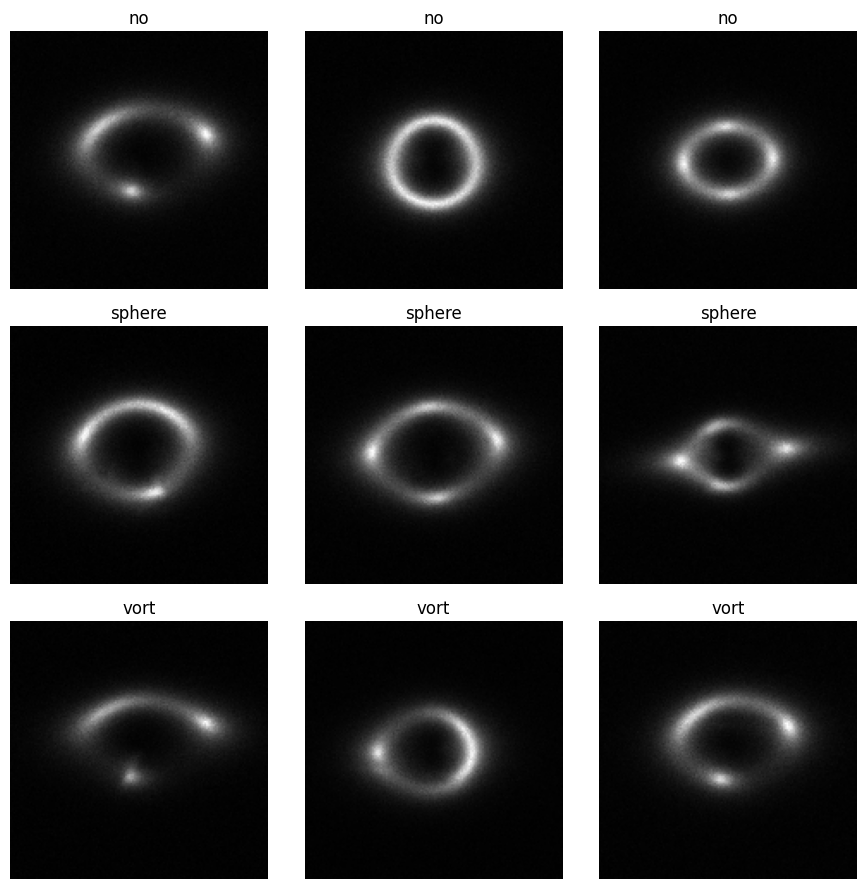

In [6]:
def show_samples(df, classes, n=3):
    fig, axes = plt.subplots(len(classes), n, figsize=(3*n, 3*len(classes)))

    if len(classes) == 1:
        axes = np.array([axes])

    for row_idx, cls in enumerate(classes):
        cls_df = df[df["label_name"] == cls].sample(
            n=min(n, len(df[df["label_name"] == cls])),
            random_state=SEED
        )

        for col_idx, (_, row) in enumerate(cls_df.iterrows()):
            img = np.load(row["path"])

            # Fix shapes like (1, H, W) or (H, W, 1)
            if img.ndim == 3:
                if img.shape[0] == 1:       # (1, H, W)
                    img = img[0]
                elif img.shape[-1] == 1:    # (H, W, 1)
                    img = img[..., 0]

            ax = axes[row_idx, col_idx]
            ax.imshow(img, cmap="gray")
            ax.set_title(cls)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_df, classes, n=3)

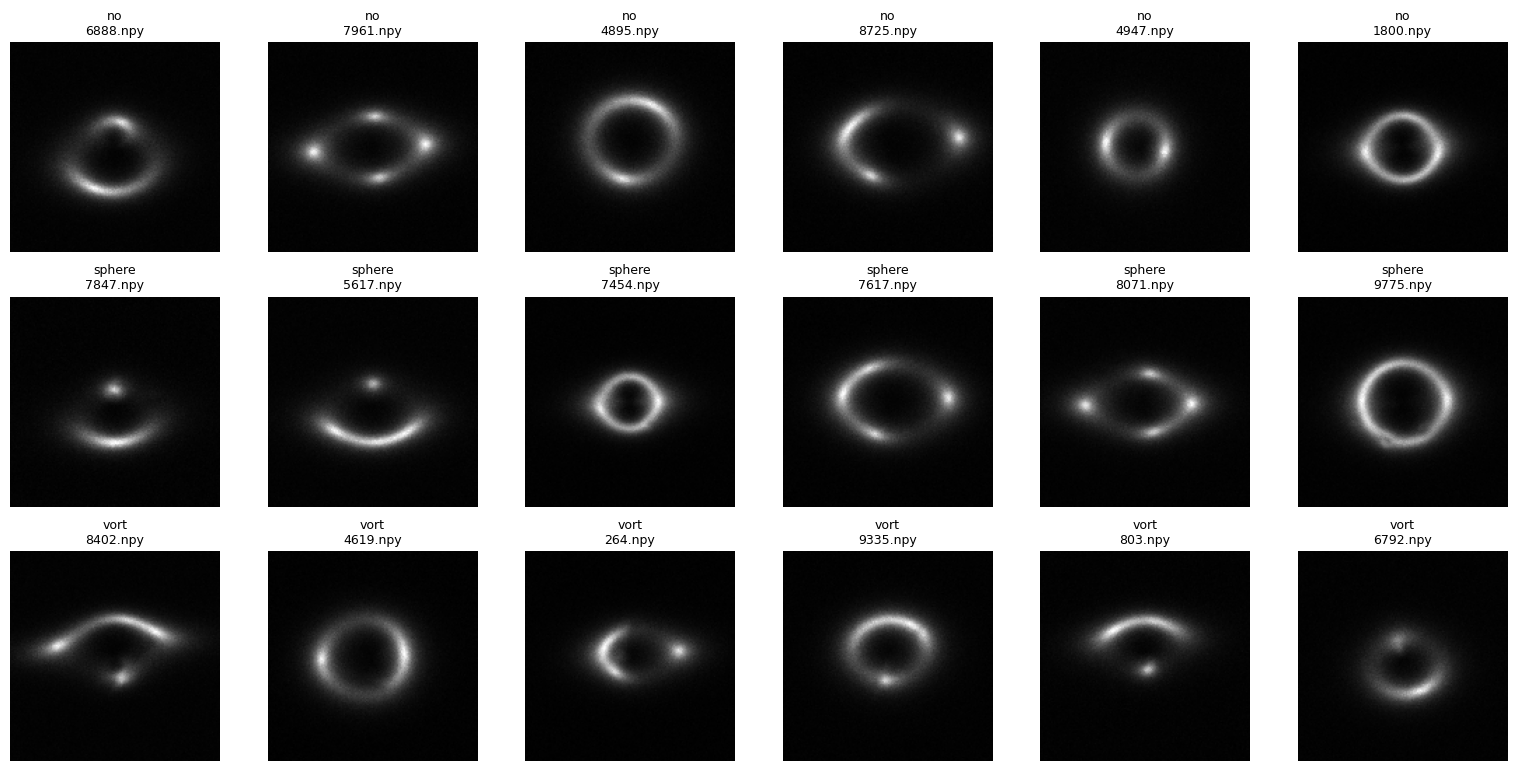

In [7]:
def load_image_for_display(path):
    img = np.load(path).astype(np.float32)

    if img.ndim == 3 and img.shape[0] == 1:      # (1, H, W)
        img = img[0]
    elif img.ndim == 3 and img.shape[-1] == 1:   # (H, W, 1)
        img = img[..., 0]
    elif img.ndim != 2:
        raise ValueError(f"Unexpected shape: {img.shape}")

    return img

def show_samples_grid(df, classes, n_per_class=6, seed=42, figsize_scale=2.6):
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(len(classes), n_per_class,
                             figsize=(figsize_scale*n_per_class, figsize_scale*len(classes)))

    if len(classes) == 1:
        axes = np.array([axes])

    for row_idx, cls in enumerate(classes):
        cls_df = df[df["label_name"] == cls]
        n = min(n_per_class, len(cls_df))
        sampled_idx = rng.choice(len(cls_df), size=n, replace=False)

        for col_idx in range(n_per_class):
            ax = axes[row_idx, col_idx]
            ax.axis("off")

            if col_idx < n:
                row = cls_df.iloc[sampled_idx[col_idx]]
                img = load_image_for_display(row["path"])
                ax.imshow(img, cmap="gray")
                ax.set_title(f"{cls}\n{Path(row['path']).name}", fontsize=9)

    plt.tight_layout()
    plt.show()

show_samples_grid(train_df, classes, n_per_class=6)

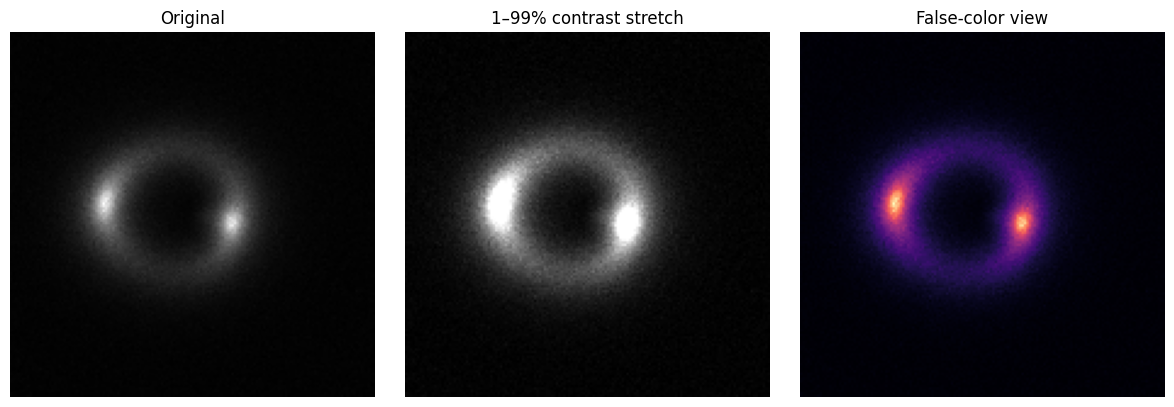

In [8]:
def show_contrast_views(path):
    img = load_image_for_display(path)

    p1, p99 = np.percentile(img, [1, 99])
    img_clip = np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(img_clip, cmap="gray")
    axes[1].set_title("1–99% contrast stretch")
    axes[1].axis("off")

    axes[2].imshow(img, cmap="magma")
    axes[2].set_title("False-color view")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

sample_path = train_df.sample(1, random_state=42).iloc[0]["path"]
show_contrast_views(sample_path)



In [9]:
def plot_class_mean_images(df, classes, max_images_per_class=300):
    fig, axes = plt.subplots(1, len(classes), figsize=(5*len(classes), 4))

    if len(classes) == 1:
        axes = [axes]

    for i, cls in enumerate(classes):
        cls_df = df[df["label_name"] == cls]
        cls_df = cls_df.sample(min(max_images_per_class, len(cls_df)), random_state=42)

        imgs = [load_image_for_display(p) for p in cls_df["path"]]
        mean_img = np.mean(np.stack(imgs, axis=0), axis=0)

        axes[i].imshow(mean_img, cmap="gray")
        axes[i].set_title(f"Mean image: {cls}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

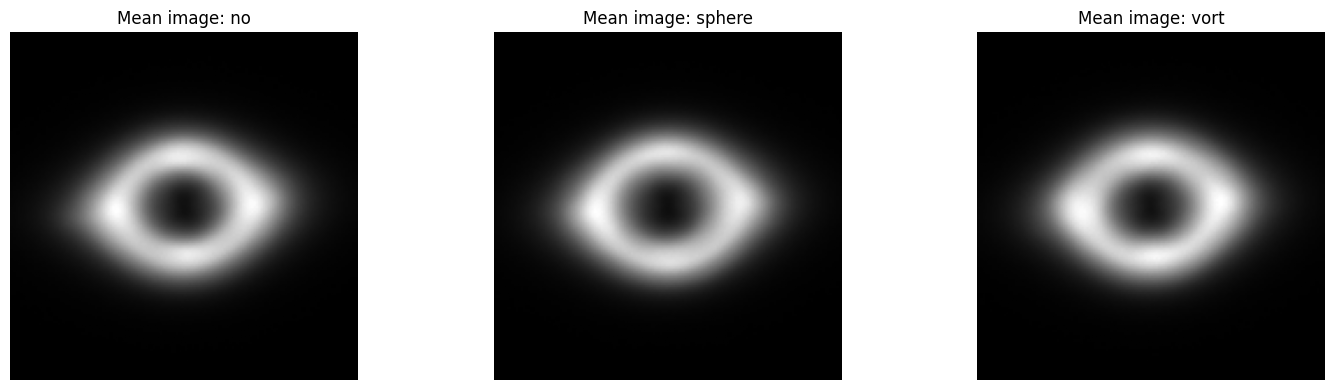

In [10]:
plot_class_mean_images(train_df, classes)

In [11]:
def plot_class_std_images(df, classes, max_images_per_class=300):
    fig, axes = plt.subplots(1, len(classes), figsize=(5*len(classes), 4))

    if len(classes) == 1:
        axes = [axes]

    for i, cls in enumerate(classes):
        cls_df = df[df["label_name"] == cls]
        cls_df = cls_df.sample(min(max_images_per_class, len(cls_df)), random_state=42)

        imgs = [load_image_for_display(p) for p in cls_df["path"]]
        std_img = np.std(np.stack(imgs, axis=0), axis=0)

        axes[i].imshow(std_img, cmap="inferno")
        axes[i].set_title(f"Std image: {cls}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()



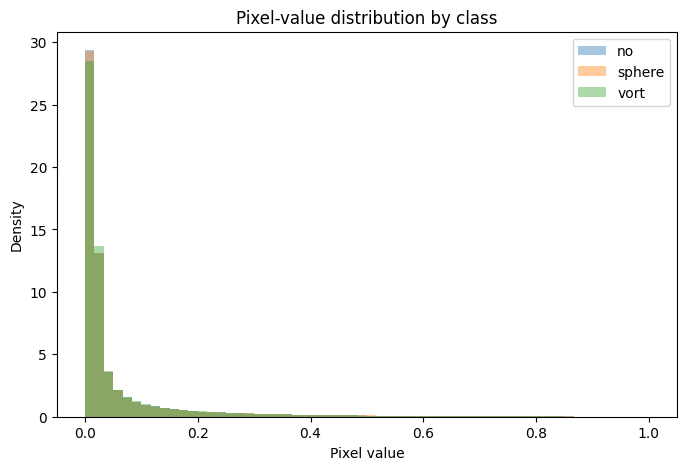

In [12]:
def plot_pixel_histograms(df, classes, max_images_per_class=150):
    plt.figure(figsize=(8, 5))

    for cls in classes:
        cls_df = df[df["label_name"] == cls]
        cls_df = cls_df.sample(min(max_images_per_class, len(cls_df)), random_state=42)

        pixels = []
        for p in cls_df["path"]:
            img = load_image_for_display(p)
            pixels.append(img.ravel())

        pixels = np.concatenate(pixels)
        plt.hist(pixels, bins=60, alpha=0.4, density=True, label=cls)

    plt.xlabel("Pixel value")
    plt.ylabel("Density")
    plt.title("Pixel-value distribution by class")
    plt.legend()
    plt.show()

plot_pixel_histograms(train_df, classes)

In [13]:
def show_class_counts(train_df, val_df):
    print("Train counts:")
    print(train_df["label_name"].value_counts())
    print()
    print("Val counts:")
    print(val_df["label_name"].value_counts())

show_class_counts(train_df, val_df)

Train counts:
label_name
no        10000
sphere    10000
vort      10000
Name: count, dtype: int64

Val counts:
label_name
no        2500
sphere    2500
vort      2500
Name: count, dtype: int64


In [14]:
sample_path = train_df.iloc[0]["path"]
sample = np.load(sample_path)

print("Sample path:", sample_path)
print("Shape:", sample.shape)
print("Dtype:", sample.dtype)
print("Min:", sample.min(), "Max:", sample.max())

Sample path: /kaggle/input/datasets/arushhh/common-task-dataset/dataset/train/no/1.npy
Shape: (1, 150, 150)
Dtype: float64
Min: 0.0 Max: 1.0


In [15]:
class CONFIG:
    TRAIN_PATH = "/kaggle/input/datasets/arushhh/common-task-dataset/dataset/train"
    VAL_PATH = "/kaggle/input/datasets/arushhh/common-task-dataset/dataset/val"
    BATCH_SIZE = 16
    LEARNING_RATE = 1e-4
    DROPOUT = 0.30
    EPOCHS = 10
    NUM_WORKERS = 0
    SEED = 42

In [16]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG.SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

train_paths = []
val_paths = []
classes = sorted([p.name for p in Path(CONFIG.TRAIN_PATH).iterdir() if p.is_dir()])

class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
print(class_to_idx)

for c in classes:
    train_paths += [str(p) for p in (Path(CONFIG.TRAIN_PATH) / c).glob("*.npy")]
    val_paths += [str(p) for p in (Path(CONFIG.VAL_PATH) / c).glob("*.npy")]

class GSoCDeepLenseDataset(Dataset):
    def __init__(self, image_paths, train=False):
        self.image_paths = image_paths
        self.train = train

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_filepath = self.image_paths[idx]
        image = np.load(image_filepath).astype(np.float32)

        if image.ndim == 3 and image.shape[0] == 1:
            image = image
        elif image.ndim == 2:
            image = np.expand_dims(image, axis=0)
        else:
            raise ValueError(f"Unexpected shape: {image.shape}")

        x = torch.from_numpy(image)

        if self.train:
            if random.random() < 0.5:
                x = torch.flip(x, dims=[2])
            if random.random() < 0.5:
                x = torch.flip(x, dims=[1])
            if random.random() < 0.5:
                k = random.choice([1, 2, 3])
                x = torch.rot90(x, k=k, dims=[1, 2])

        label = image_filepath.split(os.sep)[-2]
        y = class_to_idx[label]
        return x, y

train_dataset = GSoCDeepLenseDataset(train_paths, train=True)
val_dataset = GSoCDeepLenseDataset(val_paths, train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG.BATCH_SIZE,
    shuffle=True,
    num_workers=CONFIG.NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG.BATCH_SIZE,
    shuffle=False,
    num_workers=CONFIG.NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

Using device: cuda
{'no': 0, 'sphere': 1, 'vort': 2}


In [17]:
class DenseNet161Model(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.backbone = timm.create_model("densenet161", pretrained=True, in_chans=1, num_classes=0)
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(CONFIG.DROPOUT),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats)


class DenseNet201Model(nn.Module):
    def __init__(self, n_classes=3):
        super().__init__()
        self.backbone = timm.create_model("densenet201", pretrained=True, in_chans=1, num_classes=0)
        in_features = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(CONFIG.DROPOUT),
            nn.Linear(512, n_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.classifier(feats)

In [18]:
criterion = nn.CrossEntropyLoss()

@torch.no_grad()
def get_probs_and_labels(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    return all_labels, all_preds, all_probs


def macro_auc_score(y_true, y_prob, n_classes=3):
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))
    return roc_auc_score(y_true_bin, y_prob, multi_class="ovr", average="macro")


def train_model(model, train_loader, val_loader, save_path):
    optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.LEARNING_RATE)
    best_auc = -1
    history = defaultdict(list)

    for epoch in range(CONFIG.EPOCHS):
        model.train()
        running_loss = 0.0
        total = 0

        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG.EPOCHS}"):
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            total += xb.size(0)

        train_loss = running_loss / total

        y_val, y_pred, y_prob = get_probs_and_labels(model, val_loader)
        val_auc = macro_auc_score(y_val, y_prob, n_classes=len(classes))

        history["train_loss"].append(train_loss)
        history["val_macro_auc"].append(val_auc)

        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_macro_auc={val_auc:.4f}")

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model to {save_path} with macro AUC = {best_auc:.4f}")

    return history, best_auc

In [19]:
densenet161_model = DenseNet161Model(n_classes=len(classes)).to(device)
history_161, best_auc_161 = train_model(
    densenet161_model,
    train_loader,
    val_loader,
    save_path="densenet161_best.pth"
)

model.safetensors:   0%|          | 0.00/116M [00:00<?, ?B/s]

Epoch 1/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1: train_loss=0.6777, val_macro_auc=0.9476
Saved best model to densenet161_best.pth with macro AUC = 0.9476


Epoch 2/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2: train_loss=0.3897, val_macro_auc=0.9733
Saved best model to densenet161_best.pth with macro AUC = 0.9733


...

Epoch 8: train_loss=0.2021, val_macro_auc=0.9868


Epoch 9/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 9: train_loss=0.1941, val_macro_auc=0.9881
Saved best model to densenet161_best.pth with macro AUC = 0.9881


Epoch 10/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 10: train_loss=0.1762, val_macro_auc=0.9900
Saved best model to densenet161_best.pth with macro AUC = 0.9900


In [20]:
del densenet161_model
torch.cuda.empty_cache()
gc.collect()

densenet201_model = DenseNet201Model(n_classes=len(classes)).to(device)
history_201, best_auc_201 = train_model(
    densenet201_model,
    train_loader,
    val_loader,
    save_path="densenet201_best.pth"
)

model.safetensors:   0%|          | 0.00/81.1M [00:00<?, ?B/s]

Epoch 1/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 1: train_loss=0.7622, val_macro_auc=0.9491
Saved best model to densenet201_best.pth with macro AUC = 0.9491


Epoch 2/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2: train_loss=0.4250, val_macro_auc=0.9677
Saved best model to densenet201_best.pth with macro AUC = 0.9677


...

Epoch 8: train_loss=0.2071, val_macro_auc=0.9855
Saved best model to densenet201_best.pth with macro AUC = 0.9855


Epoch 9/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 9: train_loss=0.1994, val_macro_auc=0.9888
Saved best model to densenet201_best.pth with macro AUC = 0.9888


Epoch 10/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 10: train_loss=0.1863, val_macro_auc=0.9844


In [21]:
@torch.no_grad()
def ensemble_predict_proba(model1, model2, loader):
    model1.eval()
    model2.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits1 = model1(xb)
        logits2 = model2(xb)

        probs1 = F.softmax(logits1, dim=1)
        probs2 = F.softmax(logits2, dim=1)

        probs = (probs1 + probs2) / 2.0
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())
        all_labels.append(yb.cpu().numpy())

    return (
        np.concatenate(all_labels),
        np.concatenate(all_preds),
        np.concatenate(all_probs)
    )

In [22]:
densenet161_model = DenseNet161Model(n_classes=len(classes)).to(device)
densenet201_model = DenseNet201Model(n_classes=len(classes)).to(device)

densenet161_model.load_state_dict(torch.load("densenet161_best.pth", map_location=device))
densenet201_model.load_state_dict(torch.load("densenet201_best.pth", map_location=device))

y_true_ens, y_pred_ens, y_prob_ens = ensemble_predict_proba(
    densenet161_model,
    densenet201_model,
    val_loader
)

ensemble_macro_auc = macro_auc_score(y_true_ens, y_prob_ens, n_classes=len(classes))
print("Ensemble macro AUC:", ensemble_macro_auc)
print(classification_report(y_true_ens, y_pred_ens, target_names=classes))

Ensemble macro AUC: 0.9919410933333334
              precision    recall  f1-score   support

          no       0.91      0.99      0.95      2500
      sphere       0.97      0.91      0.94      2500
        vort       0.97      0.95      0.96      2500

    accuracy                           0.95      7500
   macro avg       0.95      0.95      0.95      7500
weighted avg       0.95      0.95      0.95      7500



In [23]:
def plot_conf_matrix(y_true, y_pred, classes, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 5))
    plt.imshow(cm)
    plt.xticks(range(len(classes)), classes)
    plt.yticks(range(len(classes)), classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)

    for i in range(len(classes)):
        for j in range(len(classes)):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.colorbar()
    plt.tight_layout()
    plt.show()


def plot_roc_multiclass(y_true, y_prob, classes, title="ROC Curves"):
    y_true_bin = label_binarize(y_true, classes=np.arange(len(classes)))

    plt.figure(figsize=(7, 5))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        auc_i = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc_i:.3f})")

    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

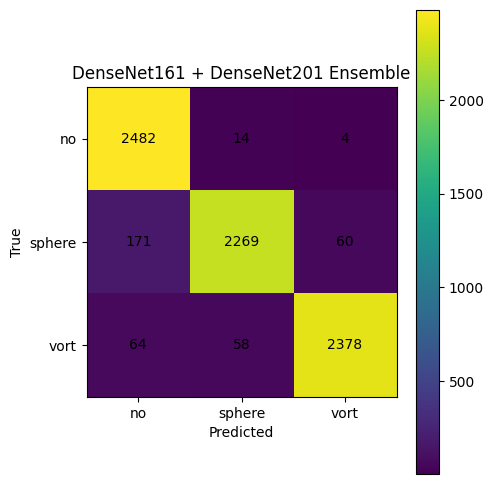

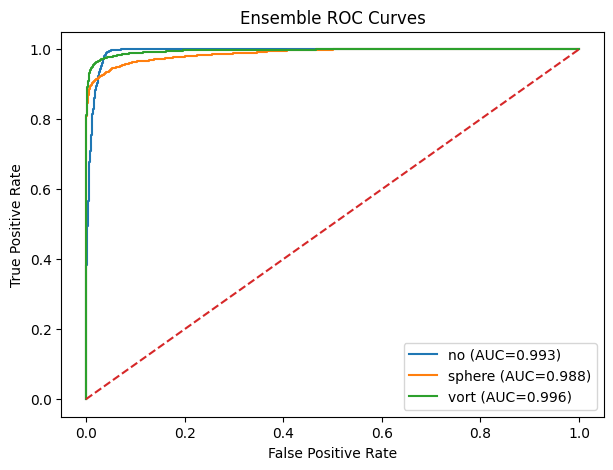

In [24]:
plot_conf_matrix(y_true_ens, y_pred_ens, classes, title="DenseNet161 + DenseNet201 Ensemble")
plot_roc_multiclass(y_true_ens, y_prob_ens, classes, title="Ensemble ROC Curves")